In [ ]:
import pandas as pd
df = pd.read_csv('/content/retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print("shape:",df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

shape: (1000, 9)

Column Names:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [ ]:
print("Mean:")
print(df.mean(numeric_only=True))

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nMode:")
print(df.mode(numeric_only=True).iloc[0])

print("\nStandard Deviation:")
print(df.std(numeric_only=True))

Mean:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('retail_sales_dataset.csv')


In [ ]:
print(df.head())

   Transaction ID       Date Customer ID  Gender  Age Product Category  \
0               1 2023-11-24     CUST001    Male   34           Beauty   
1               2 2023-02-27     CUST002  Female   26         Clothing   
2               3 2023-01-13     CUST003    Male   50      Electronics   
3               4 2023-05-21     CUST004    Male   37         Clothing   
4               5 2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount    Month  
0         3              50           150  2023-11  
1         2             500          1000  2023-02  
2         1              30            30  2023-01  
3         1             500           500  2023-05  
4         2              50           100  2023-05  


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month']=df['Date'].dt.to_period('M')

monthly_sales=df.groupby('Month')['Total Amount'].sum()

print(monthly_sales)

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


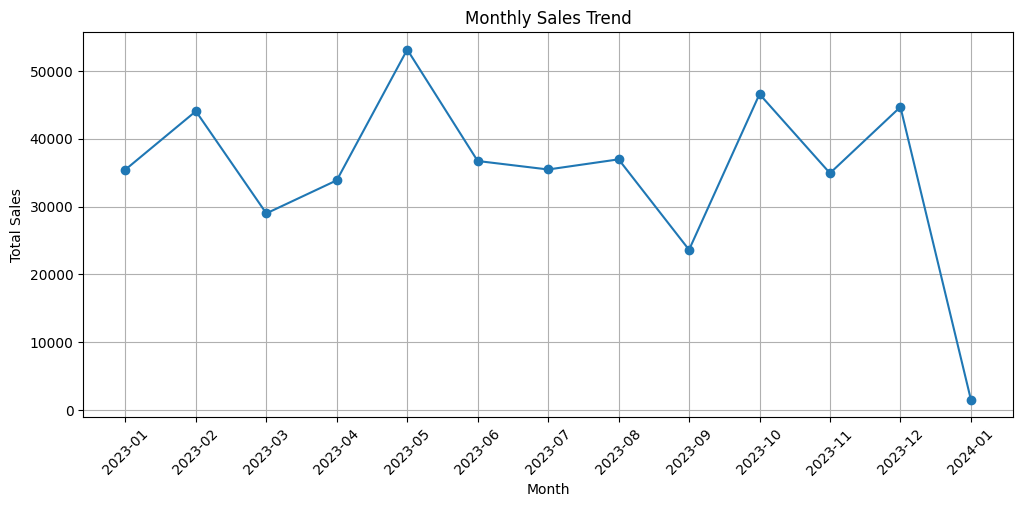

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index.astype(str),monthly_sales.values,marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd

df=pd.read_csv('retail_sales_dataset.csv')

In [ ]:
df['Date']=pd.to_datetime(df['Date'])

In [ ]:
df['Quater'] = df['Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quater')['Total Amount'].sum()

print(quarterly_sales)

Quater
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64


In [ ]:
import matplotlib.pyplot as plt


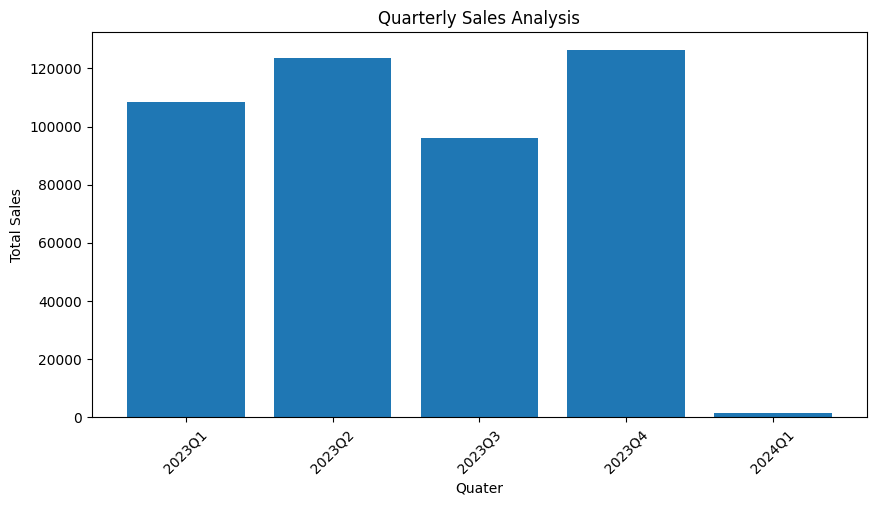

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(quarterly_sales.index.astype(str),quarterly_sales.values)

plt.title('Quarterly Sales Analysis')
plt.xlabel('Quater')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

In [ ]:
gender_sales=df.groupby('Gender')['Total Amount'].sum()
print(gender_sales)

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


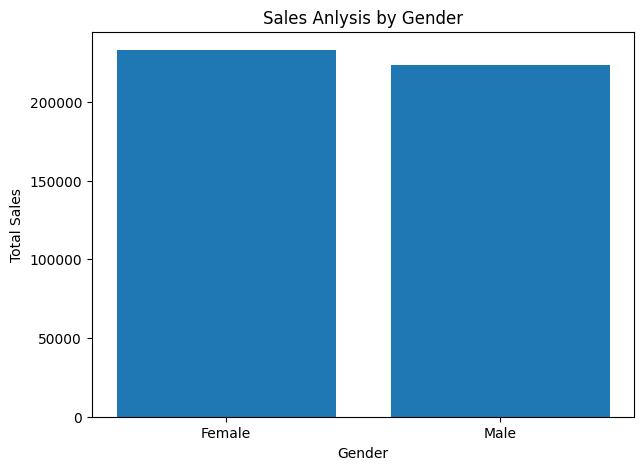

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(gender_sales.index,gender_sales.values)

plt.title('Sales Anlysis by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')

plt.show()

In [ ]:
age_stats = df['Age'].describe()
print(age_stats)

count    1000.00000
mean       41.39200
std        13.68143
min        18.00000
25%        29.00000
50%        42.00000
75%        53.00000
max        64.00000
Name: Age, dtype: float64


In [ ]:
age_bins = [0,18,25,35,45,55,100]
age_labels = ['0-18','19-25','26-35','36-45','46-55','56+']

df['Age Group'] = pd.cut(df['Age'],bins=age_bins,labels=age_labels,right=False)

age_group_sales = df.groupby('Age Group')['Total Amount'].sum()

print(age_group_sales)

Age Group
0-18         0
19-25    74650
26-35    97090
36-45    96835
46-55    97235
56+      90190
Name: Total Amount, dtype: int64


/tmp/ipykernel_1836/2061617459.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_sales = df.groupby('Age Group')['Total Amount'].sum()


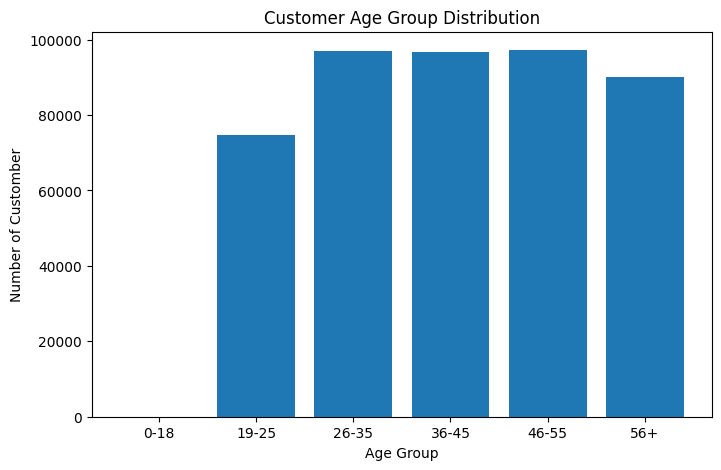

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(age_group_sales.index.astype(str),age_group_sales.values)

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customber')

plt.show()

In [ ]:
top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False).head(5)
print(top_products)

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


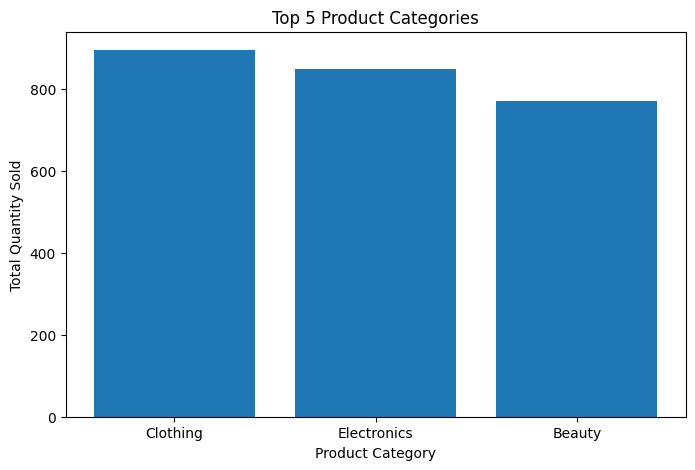

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(top_products.index,top_products.values)

plt.title('Top 5 Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')

plt.show()

In [ ]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()
print(category_sales)

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


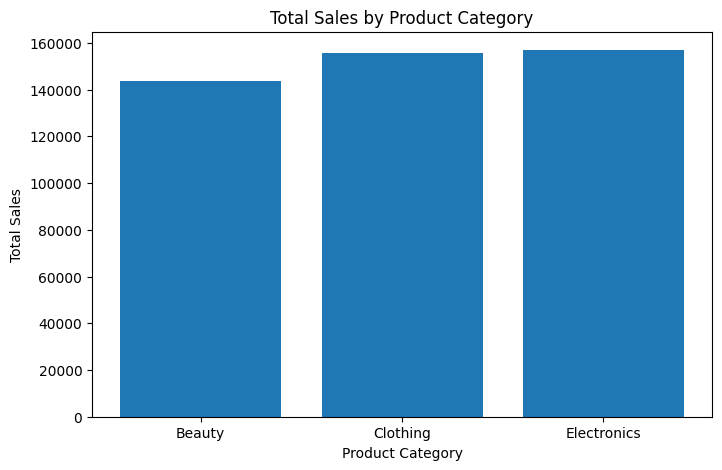

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(category_sales.index,category_sales.values)

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')

plt.show()

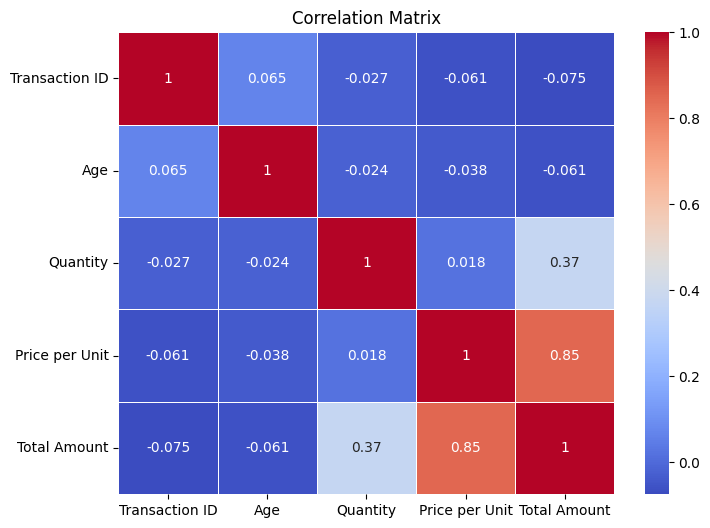

In [ ]:
import seaborn as sns

numeric_data = df.select_dtypes(include=['number'])

correlation = numeric_data.corr()

plt.figure(figsize=(8,6))

sns.heatmap(correlation,annot=True,cmap='coolwarm',linewidths=0.5)

plt.title('Correlation Matrix')

plt.show()

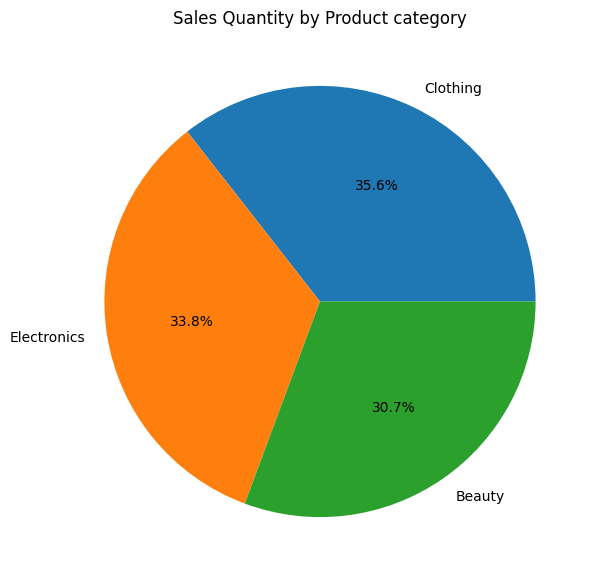

In [ ]:
plt.figure(figsize=(7,7))

plt.pie(top_products.values,labels=top_products.index,autopct='%1.1f%%')

plt.title('Sales Quantity by Product category')

plt.show()

BUSINESS RECOMMENDATION


1.   The company can keep more stock of the products that are selling well and promote them more.
2.   Different offers can be given to different age groups based on their buying patterns.


1.   Sales promotion can be planned during periods when sales are usually lower to improve revenue.




   